# Cardiovascular Disease Prediction using Machine Learning

## Objective

To predict cardiovascular disease using various Machine Learning algorithms and compare their performance.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'cardio_train.csv', 'sample_data']


In [ ]:
df = pd.read_csv("/content/cardio_train.csv", sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [ ]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Remove ID column
df.drop("id", axis=1, inplace=True)

# Convert age from days to years
df["age"] = (df["age"] / 365).astype(int)

# Create BMI feature
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)

df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,50,2,168,62.0,110,80,1,1,0,0,1,0,21.967120
1,55,1,156,85.0,140,90,3,1,0,0,1,1,34.927679
2,51,1,165,64.0,130,70,3,1,0,0,0,1,23.507805
3,48,2,169,82.0,150,100,1,1,0,0,1,1,28.710479
4,47,1,156,56.0,100,60,1,1,0,0,0,0,23.011177


In [ ]:
df.shape

(70000, 13)

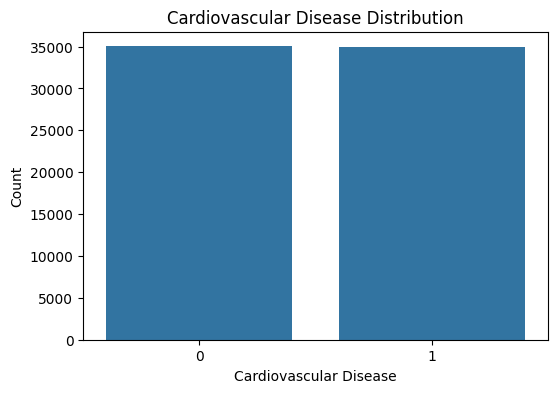

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='cardio', data=df)

plt.title("Cardiovascular Disease Distribution")
plt.xlabel("Cardiovascular Disease")
plt.ylabel("Count")

plt.show()

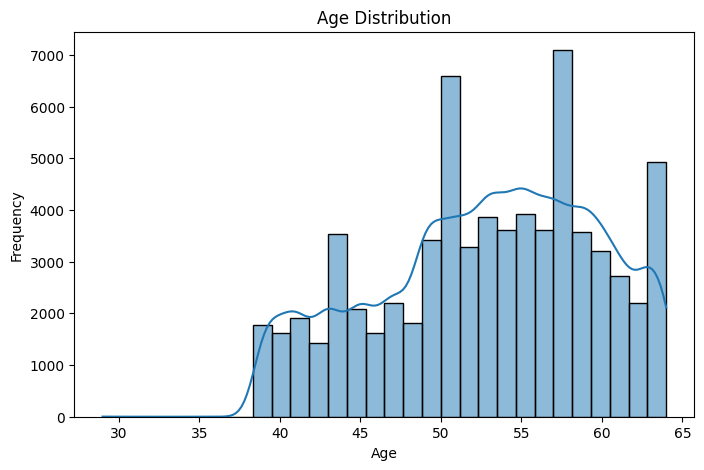

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

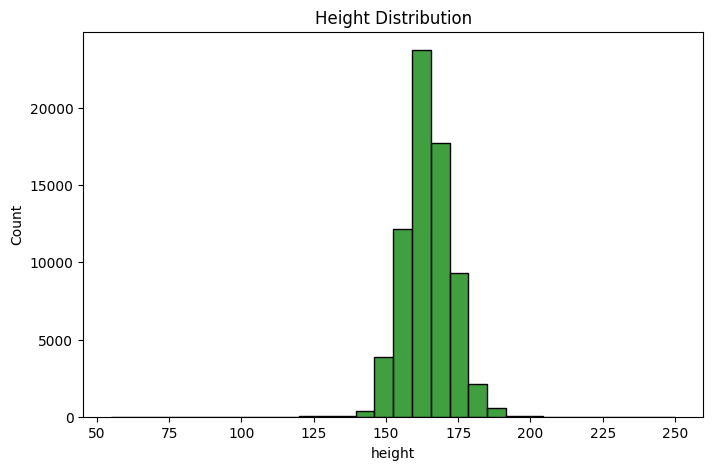

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['height'], bins=30, color='green')

plt.title("Height Distribution")

plt.show()

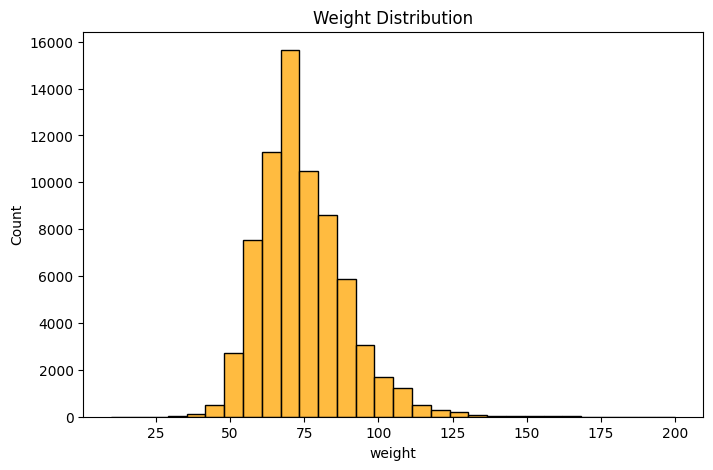

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['weight'], bins=30, color='orange')

plt.title("Weight Distribution")

plt.show()

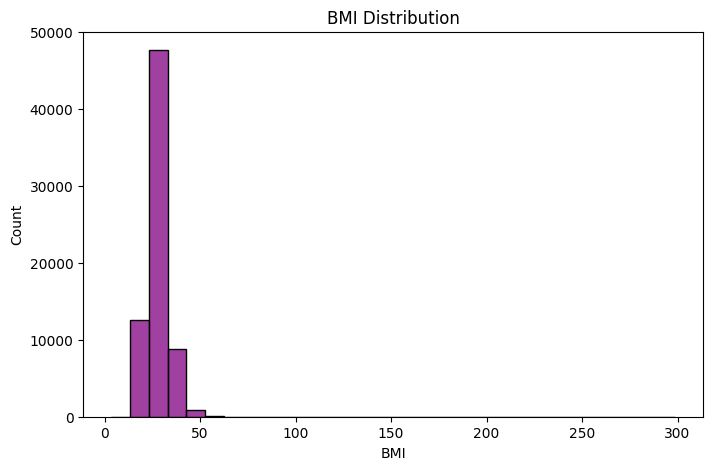

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['BMI'], bins=30, color='purple')

plt.title("BMI Distribution")

plt.show()

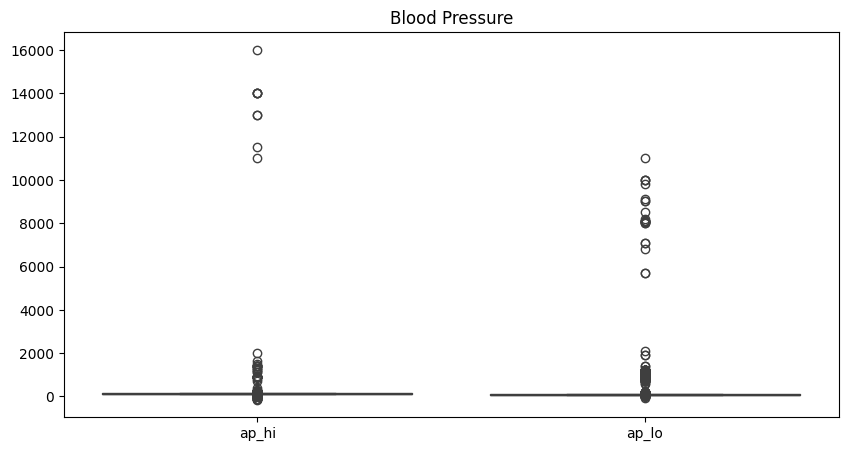

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df[['ap_hi','ap_lo']])

plt.title("Blood Pressure")

plt.show()

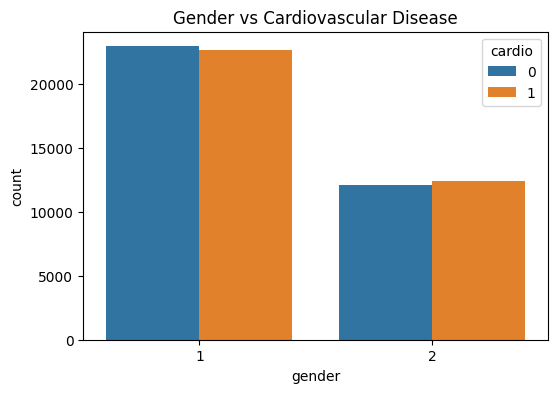

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', hue='cardio', data=df)

plt.title("Gender vs Cardiovascular Disease")

plt.show()

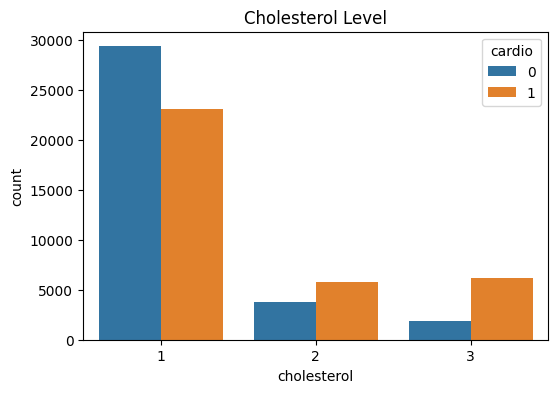

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='cholesterol', hue='cardio', data=df)

plt.title("Cholesterol Level")

plt.show()

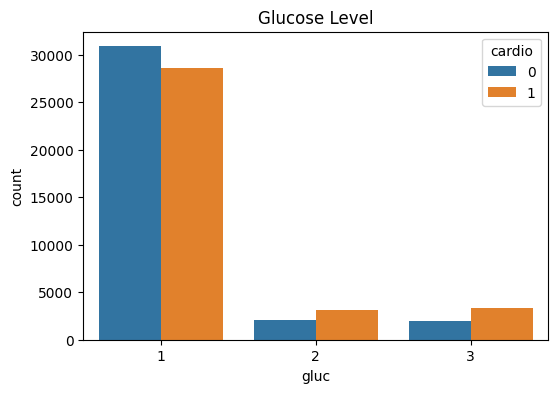

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='gluc', hue='cardio', data=df)

plt.title("Glucose Level")

plt.show()

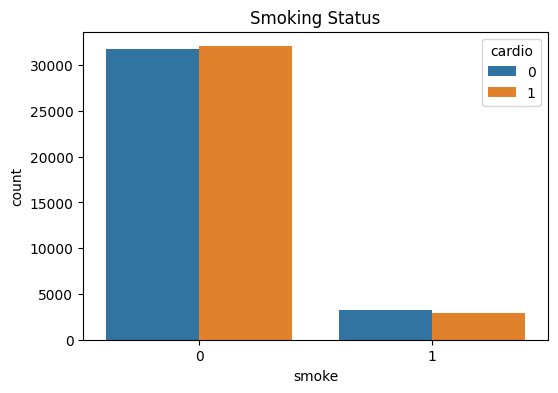

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='smoke', hue='cardio', data=df)

plt.title("Smoking Status")

plt.show()

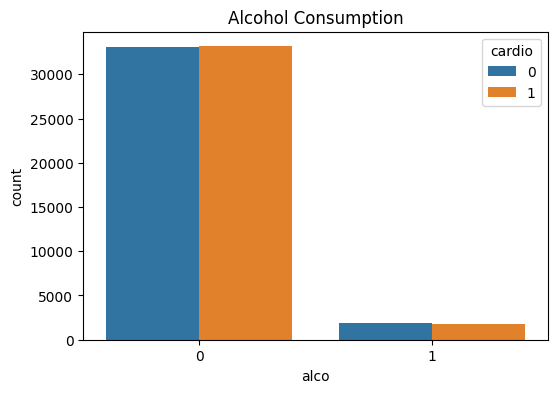

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='alco', hue='cardio', data=df)

plt.title("Alcohol Consumption")

plt.show()

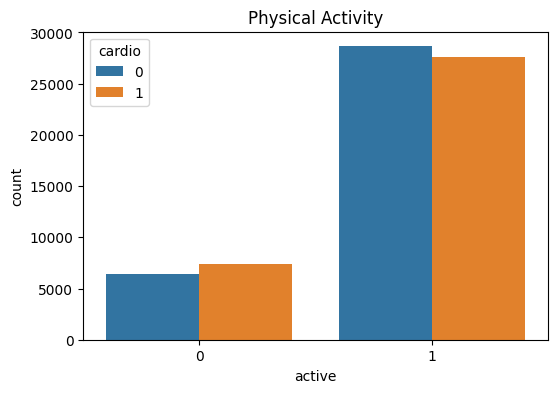

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='active', hue='cardio', data=df)

plt.title("Physical Activity")

plt.show()

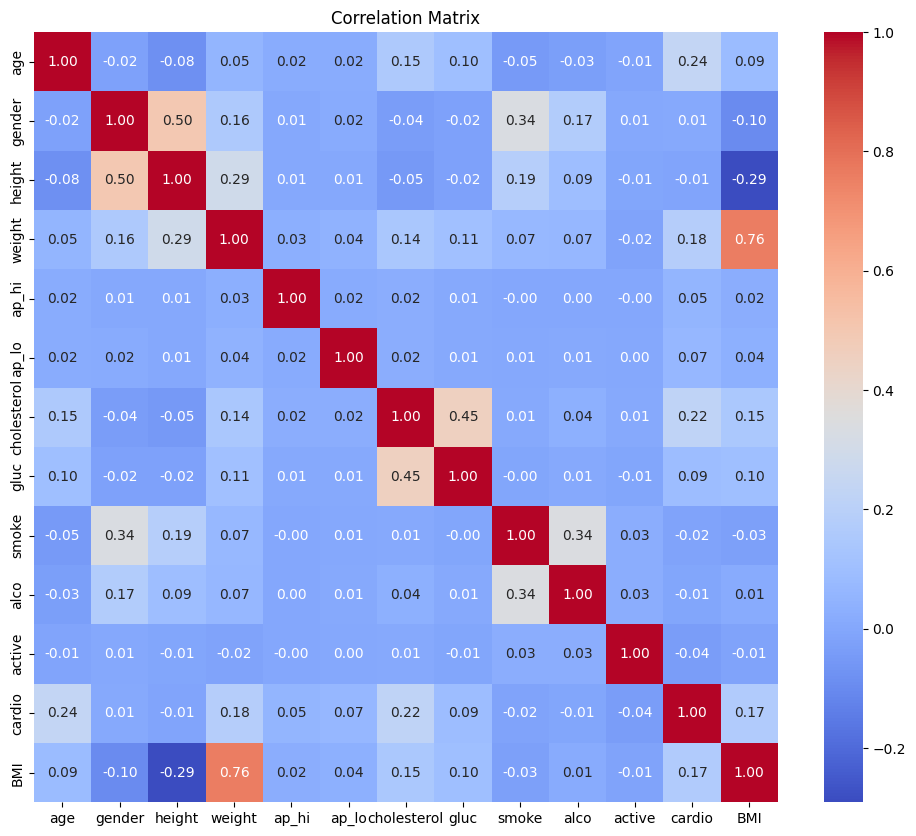

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7232857142857143


In [ ]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.7335714285714285


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.6470714285714285


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.6383571428571428


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.7090714285714286


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Support Vector Machine",
        "K-Nearest Neighbor",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_acc,
        svm_acc,
        knn_acc,
        dt_acc,
        rf_acc
    ]
})

results

,Algorithm,Accuracy
0,Logistic Regression,0.723286
1,Support Vector Machine,0.733571
2,K-Nearest Neighbor,0.647071
3,Decision Tree,0.638357
4,Random Forest,0.709071


In [ ]:
best_model = results.loc[results["Accuracy"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Algorithm    Support Vector Machine
Accuracy                   0.733571
Name: 1, dtype: object
